# PACS Learning-Curve Prediction Results

This notebook reads completed experiment outputs only. It does **not** train, fine-tune, or refit prediction models.

Run it after completing Stages 1–8. The final experiment predicts parameters of

$$
A(n)=A_0+(a-A_0)\left[1-(n+1)^{-c}\right],
$$

where $n$ is the actual number of target training examples.

Cold start predicts the full curve before target adaptation training. Warm start observes the first two adaptation budgets and predicts the remaining curve. Task-level test measurements define the ground-truth learning curves; within each outer fold, outcomes from the held-out target domain are used only for final evaluation.


In [ ]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CURRENT_DIR = Path.cwd().resolve()

if (CURRENT_DIR / "config.py").exists():
    PROJECT_ROOT = CURRENT_DIR
elif (CURRENT_DIR.parent / "config.py").exists():
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    raise FileNotFoundError(
        "Could not locate config.py. Start Jupyter from the project root "
        "or from the notebooks directory."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from config import (
    CURVE_TARGETS_CSV,
    COLD_START_DATASET_CSV,
    COLD_START_PREDICTIONS_CSV,
    COLD_START_SUMMARY_CSV,
    COLD_START_FOLD_SUMMARY_CSV,
    WARM_START_DATASET_CSV,
    WARM_START_PREDICTIONS_CSV,
    WARM_START_SUMMARY_CSV,
    WARM_START_FOLD_SUMMARY_CSV,
    COLD_RIDGE_COEFFICIENT_SUMMARY_CSV,
    COLD_RIDGE_PARAMETER_COEFFICIENTS_CSV,
    COLD_LOFO_ABLATION_CSV,
    WARM_RIDGE_COEFFICIENT_SUMMARY_CSV,
    WARM_RIDGE_PARAMETER_COEFFICIENTS_CSV,
    WARM_FEATURE_CORRELATION_MATRIX_CSV,
    WARM_FEATURE_CORRELATION_PAIRS_CSV,
    WARM_GROUPED_ABLATION_CSV,
)
from prediction import power_law_curve

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

print("Project root:", PROJECT_ROOT)


## Load completed experiment outputs


In [2]:
required_files = [
    CURVE_TARGETS_CSV,
    COLD_START_DATASET_CSV,
    COLD_START_PREDICTIONS_CSV,
    COLD_START_SUMMARY_CSV,
    COLD_START_FOLD_SUMMARY_CSV,
    WARM_START_DATASET_CSV,
    WARM_START_PREDICTIONS_CSV,
    WARM_START_SUMMARY_CSV,
    WARM_START_FOLD_SUMMARY_CSV,
    COLD_RIDGE_COEFFICIENT_SUMMARY_CSV,
    COLD_RIDGE_PARAMETER_COEFFICIENTS_CSV,
    COLD_LOFO_ABLATION_CSV,
    WARM_RIDGE_COEFFICIENT_SUMMARY_CSV,
    WARM_RIDGE_PARAMETER_COEFFICIENTS_CSV,
    WARM_FEATURE_CORRELATION_MATRIX_CSV,
    WARM_FEATURE_CORRELATION_PAIRS_CSV,
    WARM_GROUPED_ABLATION_CSV,
]

missing_files = [path for path in required_files if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        "Run the required stages before opening the results notebook. Missing files:\n"
        + "\n".join(str(path) for path in missing_files)
    )

curve_targets_df = pd.read_csv(CURVE_TARGETS_CSV)
cold_dataset_df = pd.read_csv(COLD_START_DATASET_CSV)
cold_predictions_df = pd.read_csv(COLD_START_PREDICTIONS_CSV)
cold_summary_df = pd.read_csv(COLD_START_SUMMARY_CSV)
cold_fold_df = pd.read_csv(COLD_START_FOLD_SUMMARY_CSV)
warm_dataset_df = pd.read_csv(WARM_START_DATASET_CSV)
warm_predictions_df = pd.read_csv(WARM_START_PREDICTIONS_CSV)
warm_summary_df = pd.read_csv(WARM_START_SUMMARY_CSV)
warm_fold_df = pd.read_csv(WARM_START_FOLD_SUMMARY_CSV)

cold_coefficient_summary_df = pd.read_csv(COLD_RIDGE_COEFFICIENT_SUMMARY_CSV)
cold_parameter_coefficients_df = pd.read_csv(COLD_RIDGE_PARAMETER_COEFFICIENTS_CSV)
cold_ablation_df = pd.read_csv(COLD_LOFO_ABLATION_CSV)
warm_coefficient_summary_df = pd.read_csv(WARM_RIDGE_COEFFICIENT_SUMMARY_CSV)
warm_parameter_coefficients_df = pd.read_csv(WARM_RIDGE_PARAMETER_COEFFICIENTS_CSV)
warm_correlation_df = pd.read_csv(WARM_FEATURE_CORRELATION_MATRIX_CSV, index_col=0)
warm_strongest_correlations_df = pd.read_csv(WARM_FEATURE_CORRELATION_PAIRS_CSV)
warm_grouped_ablation_df = pd.read_csv(WARM_GROUPED_ABLATION_CSV)

print("Learning-curve cases:", len(curve_targets_df))
print("Cold-start prediction rows:", len(cold_predictions_df))
print("Warm-start prediction rows:", len(warm_predictions_df))


Learning-curve cases: 96
Cold-start prediction rows: 384
Warm-start prediction rows: 768


## Ground-truth curve fits

Each case has six measured target-test points: zero shot plus the five adaptation budgets. $A_0$ is fixed to the measured zero-shot test accuracy, while $a$ and $c$ are fitted under the monotone power-law model.

These diagnostics show how well that parametric family represents the measured curves before evaluating any predictor.


In [3]:
curve_targets_df[
    [
        "curve_fit_mae",
        "curve_fit_rmse",
        "curve_fit_max_error",
    ]
].describe()


,curve_fit_mae,curve_fit_rmse,curve_fit_max_error
count,96.000000,96.000000,96.000000
mean,0.028677,0.035848,0.058683
std,0.012157,0.015013,0.025097
min,0.004147,0.005052,0.007873
25%,0.020894,0.026109,0.041314
50%,0.028415,0.036094,0.059055
75%,0.037208,0.047541,0.076470
max,0.057730,0.075324,0.140452


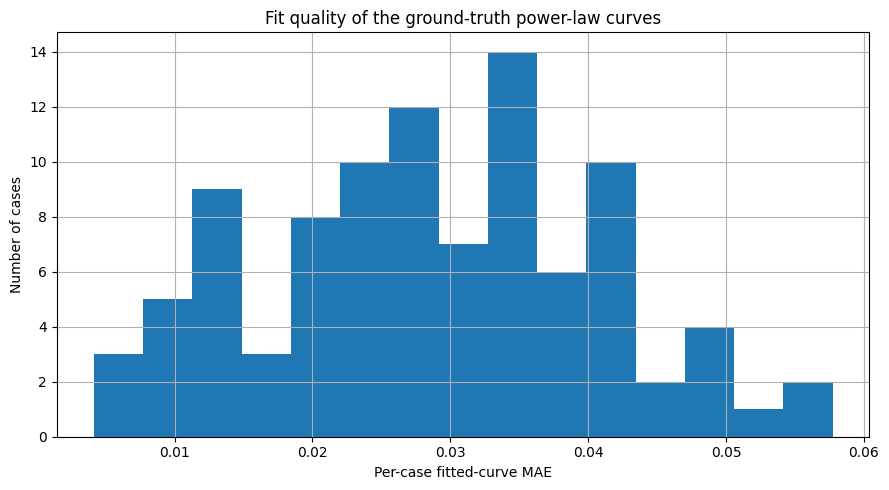

In [4]:
plt.figure(figsize=(9, 5))
plt.hist(curve_targets_df["curve_fit_mae"], bins=15)
plt.xlabel("Per-case fitted-curve MAE")
plt.ylabel("Number of cases")
plt.title("Fit quality of the ground-truth power-law curves")
plt.tight_layout()
plt.show()


## Cold-start summary

Cold start uses information available before any target adaptation training:

- source-model metadata;
- zero-shot **validation** accuracy and loss;
- source–target representation discrepancies computed on the first target subset.

Zero-shot **test** accuracy is not a predictor input. It is part of the held-out ground-truth curve.


In [5]:
cold_summary_df.sort_values("overall_mae").reset_index(drop=True)


,prediction_model,mae_0,mae_5,mae_10,mae_25,mae_50,mae_100,overall_mae
0,metadata_ridge,0.039395,0.084936,0.080479,0.099350,0.113758,0.119433,0.089559
1,metadata_distance_ridge,0.050869,0.105444,0.103989,0.122837,0.135770,0.142071,0.110163
2,mean_curve,0.116658,0.113841,0.111539,0.124787,0.130127,0.129974,0.121154
3,distance_ridge,0.108931,0.113999,0.114221,0.124989,0.136696,0.141148,0.123331


In [6]:
cold_fold_df.sort_values(
    ["held_out_target", "overall_mae"]
).reset_index(drop=True)


,fold,held_out_target,prediction_model,selected_alpha,mae_0,mae_5,mae_10,mae_25,mae_50,mae_100,overall_mae
0,1,art_painting,metadata_ridge,0.001,0.032841,0.204456,0.192589,0.189718,0.174440,0.140018,0.155677
1,1,art_painting,metadata_distance_ridge,1.000,0.042644,0.211566,0.199421,0.196205,0.180682,0.146029,0.162758
2,1,art_painting,mean_curve,NaN,0.091723,0.246686,0.232607,0.227141,0.210107,0.174083,0.197058
3,1,art_painting,distance_ridge,0.100,0.166725,0.272596,0.253579,0.242277,0.221294,0.181685,0.223026
4,2,cartoon,distance_ridge,0.001,0.052543,0.059022,0.055513,0.055251,0.074865,0.096458,0.065609
5,2,cartoon,mean_curve,NaN,0.080669,0.047554,0.048089,0.065648,0.082534,0.101005,0.070917
6,2,cartoon,metadata_ridge,1.000,0.030686,0.044821,0.044824,0.080340,0.104302,0.128015,0.072165
7,2,cartoon,metadata_distance_ridge,1.000,0.037196,0.049662,0.055938,0.098300,0.127808,0.152423,0.086888
8,3,photo,metadata_ridge,0.100,0.025852,0.046770,0.043884,0.071592,0.112550,0.137549,0.073033
9,3,photo,metadata_distance_ridge,0.100,0.029569,0.049841,0.065710,0.114318,0.161141,0.191079,0.101943


### Cold-start model ranking


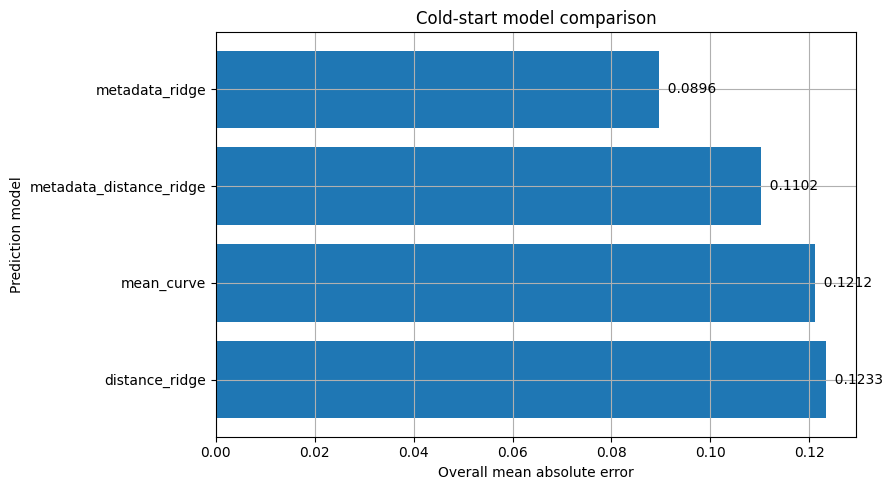

In [7]:
cold_ranking_df = (
    cold_summary_df
    .sort_values("overall_mae")
    .reset_index(drop=True)
)

plt.figure(figsize=(9, 5))
bars = plt.barh(
    cold_ranking_df["prediction_model"],
    cold_ranking_df["overall_mae"],
)

plt.xlabel("Overall mean absolute error")
plt.ylabel("Prediction model")
plt.title("Cold-start model comparison")
plt.gca().invert_yaxis()

for bar, mae in zip(
    bars,
    cold_ranking_df["overall_mae"],
):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"  {mae:.4f}",
        va="center",
    )

plt.tight_layout()
plt.show()


### Cold-start error by nominal budget

The columns 5, 10, 25, 50, and 100 identify the nested experimental budgets. Their actual sample counts vary by target domain, so this aggregate figure uses the nominal budget labels. Case-level learning-curve plots below use the exact $n$.


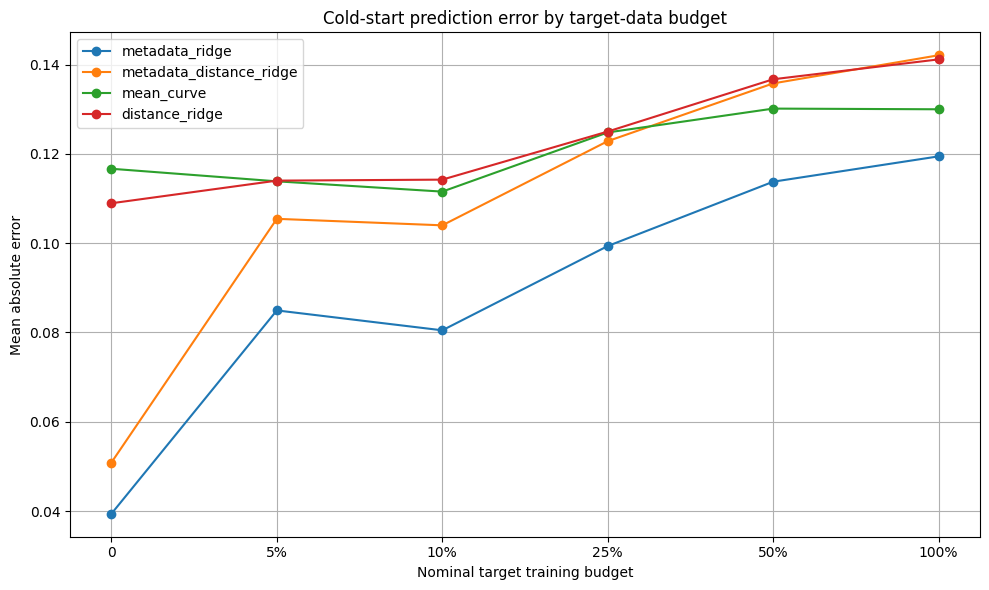

In [8]:
cold_points = [0, 5, 10, 25, 50, 100]
cold_model_names = cold_summary_df["prediction_model"].tolist()
x_positions = np.arange(len(cold_points))

plt.figure(figsize=(10, 6))

for prediction_model in cold_model_names:
    row = cold_summary_df[
        cold_summary_df["prediction_model"] == prediction_model
    ].iloc[0]

    plt.plot(
        x_positions,
        [row[f"mae_{point}"] for point in cold_points],
        marker="o",
        label=prediction_model,
    )

plt.xticks(
    x_positions,
    ["0"] + [f"{point}%" for point in cold_points[1:]],
)
plt.xlabel("Nominal target training budget")
plt.ylabel("Mean absolute error")
plt.title("Cold-start prediction error by target-data budget")
plt.legend()
plt.tight_layout()
plt.show()


### Cold-start error by held-out target domain


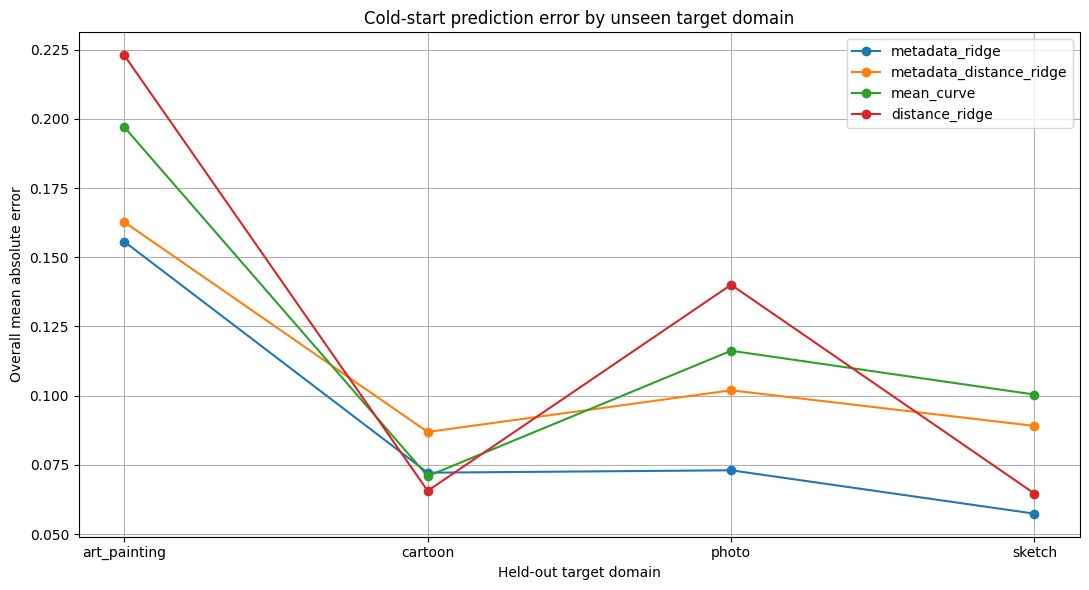

In [9]:
cold_targets = sorted(
    cold_fold_df["held_out_target"].unique()
)
x_positions = np.arange(len(cold_targets))

plt.figure(figsize=(11, 6))

for prediction_model in cold_model_names:
    target_maes = []

    for held_out_target in cold_targets:
        row = cold_fold_df[
            (cold_fold_df["prediction_model"] == prediction_model)
            & (cold_fold_df["held_out_target"] == held_out_target)
        ].iloc[0]

        target_maes.append(row["overall_mae"])

    plt.plot(
        x_positions,
        target_maes,
        marker="o",
        label=prediction_model,
    )

plt.xticks(x_positions, cold_targets)
plt.xlabel("Held-out target domain")
plt.ylabel("Overall mean absolute error")
plt.title("Cold-start prediction error by unseen target domain")
plt.legend()
plt.tight_layout()
plt.show()


### Example cold-start learning curve

The markers are the measured target-test accuracies. The solid ground-truth line is the fitted power-law representation of those measurements. Each predictor is drawn as a continuous curve from its predicted $[A_0,a,c]$ parameters.

Change `example_cold_case_id` to inspect any case.


In [10]:
def plot_cold_start_case(
    predictions_df,
    case_id,
    prediction_models=None,
):
    case_df = predictions_df[
        predictions_df["case_id"] == case_id
    ].copy()

    if case_df.empty:
        raise ValueError(f"Unknown case_id: {case_id}")

    if prediction_models is not None:
        case_df = case_df[
            case_df["prediction_model"].isin(prediction_models)
        ]

    if case_df.empty:
        raise ValueError(
            "No rows remain after applying prediction_models."
        )

    first_row = case_df.iloc[0]
    points = [0, 5, 10, 25, 50, 100]

    n_values = np.array(
        [first_row[f"n_{point}"] for point in points],
        dtype=float,
    )
    actual_values = np.array(
        [first_row[f"actual_{point}"] for point in points],
        dtype=float,
    )

    dense_n = np.linspace(0, n_values.max(), 400)

    actual_parameters = [
        first_row["actual_curve_a0"],
        first_row["actual_curve_a"],
        first_row["actual_curve_c"],
    ]
    fitted_actual_curve = power_law_curve(
        dense_n,
        *actual_parameters,
    )

    plt.figure(figsize=(10, 6))

    plt.plot(
        dense_n,
        fitted_actual_curve,
        linewidth=3,
        label="fitted ground-truth curve",
    )
    plt.scatter(
        n_values,
        actual_values,
        s=70,
        label="measured test accuracy",
        zorder=5,
    )

    for _, row in case_df.iterrows():
        predicted_parameters = [
            row["predicted_curve_a0"],
            row["predicted_curve_a"],
            row["predicted_curve_c"],
        ]

        plt.plot(
            dense_n,
            power_law_curve(
                dense_n,
                *predicted_parameters,
            ),
            linestyle="--",
            label=row["prediction_model"],
        )

    plt.xlabel("Number of target training examples (n)")
    plt.ylabel("Target test accuracy")
    plt.title(
        "Cold-start learning-curve prediction\n"
        f"{first_row['sources']} → {first_row['target']} | "
        f"{first_row['model']} | seed {int(first_row['seed'])}"
    )
    plt.ylim(0.0, 1.0)
    plt.legend()
    plt.tight_layout()
    plt.show()


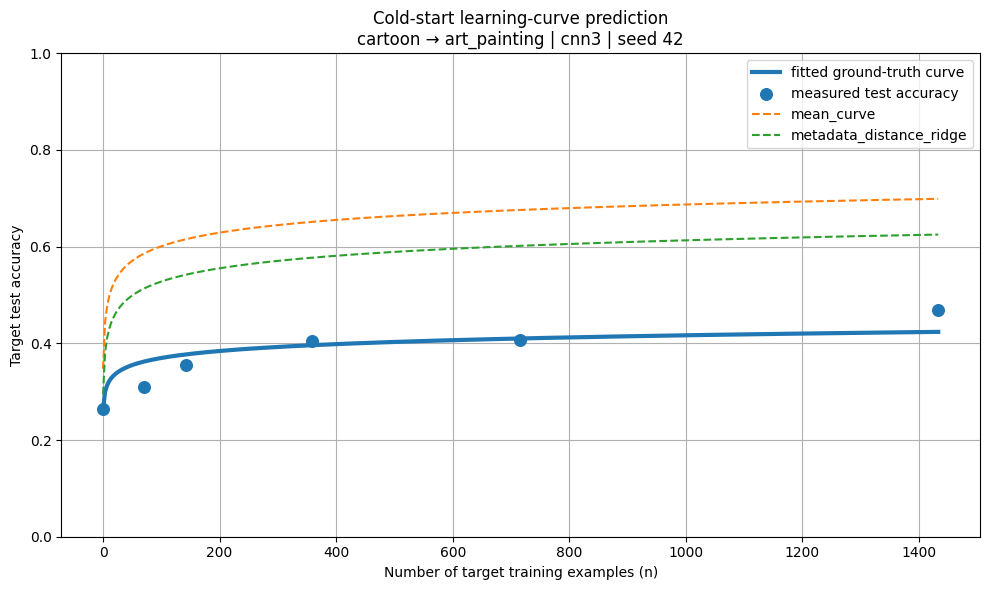

In [11]:
example_cold_case_id = cold_predictions_df["case_id"].iloc[0]

plot_cold_start_case(
    cold_predictions_df,
    case_id=example_cold_case_id,
    prediction_models=[
        "mean_curve",
        "metadata_distance_ridge",
    ],
)


## Warm-start summary

Warm start assumes that zero-shot evaluation and the 5% and 10% adaptation runs have already been completed. The observed inputs are training/validation quantities; target-test accuracy remains evaluation-only.

The Ridge variants predict the power-law parameters $[A_0,a,c]$ and are evaluated only on the future 25%, 50%, and 100% budgets. The three-point log baseline is separate: it fits a log curve directly to the observed validation accuracies at $n=0$, $n=n_5$, and $n=n_{10}$.

The warm-start discrepancy ablation distinguishes three kinds of representation information:

- **source discrepancy**: source–target discrepancy under the original source model;
- **adapted discrepancy**: source–target discrepancy under the 10%-adapted model;
- **discrepancy change**: adapted discrepancy minus source discrepancy, preserving the sign of the shift.


In [12]:
warm_summary_df.sort_values("overall_mae").reset_index(drop=True)


,prediction_model,mae_25,mae_50,mae_100,overall_mae
0,three_point_log_curve,0.039799,0.050018,0.066431,0.052083
1,metadata_observation_ridge,0.050907,0.061585,0.067529,0.060007
2,metadata_observation_change_ridge,0.057431,0.070533,0.077773,0.068579
3,observation_ridge,0.060315,0.072369,0.080534,0.071073
4,metadata_observation_source_ridge,0.059730,0.077027,0.086354,0.074371
5,metadata_observation_adapted_ridge,0.062943,0.078298,0.086858,0.076033
6,metadata_observation_adapted_change_ridge,0.067704,0.084202,0.092306,0.081404
7,mean_remaining_curve,0.124787,0.130127,0.129974,0.128296


In [13]:
warm_fold_df.sort_values(
    ["held_out_target", "overall_mae"]
).reset_index(drop=True)


,fold,held_out_target,prediction_model,selected_alpha,mae_25,mae_50,mae_100,overall_mae
0,1,art_painting,three_point_log_curve,NaN,0.036377,0.030714,0.067501,0.044864
1,1,art_painting,metadata_observation_adapted_ridge,1.000,0.098843,0.084127,0.062915,0.081962
2,1,art_painting,metadata_observation_ridge,1.000,0.100258,0.084832,0.061599,0.082230
3,1,art_painting,metadata_observation_change_ridge,1.000,0.102498,0.086882,0.064849,0.084743
4,1,art_painting,metadata_observation_source_ridge,1.000,0.104920,0.090710,0.061920,0.085850
5,1,art_painting,metadata_observation_adapted_change_ridge,0.100,0.114372,0.099834,0.069545,0.094584
6,1,art_painting,observation_ridge,1.000,0.118190,0.110133,0.086623,0.104982
7,1,art_painting,mean_remaining_curve,NaN,0.227141,0.210107,0.174083,0.203777
8,2,cartoon,observation_ridge,0.100,0.023298,0.029423,0.046900,0.033207
9,2,cartoon,three_point_log_curve,NaN,0.027654,0.040336,0.051605,0.039865


### Warm-start model ranking

The main comparison is within the warm-start setting: Ridge predictors are compared with the mean-remaining-curve and three-point logarithmic baselines. Cold-start and warm-start MAEs are not treated as a primary comparison because the two settings use different available information and predict different portions of the curve.


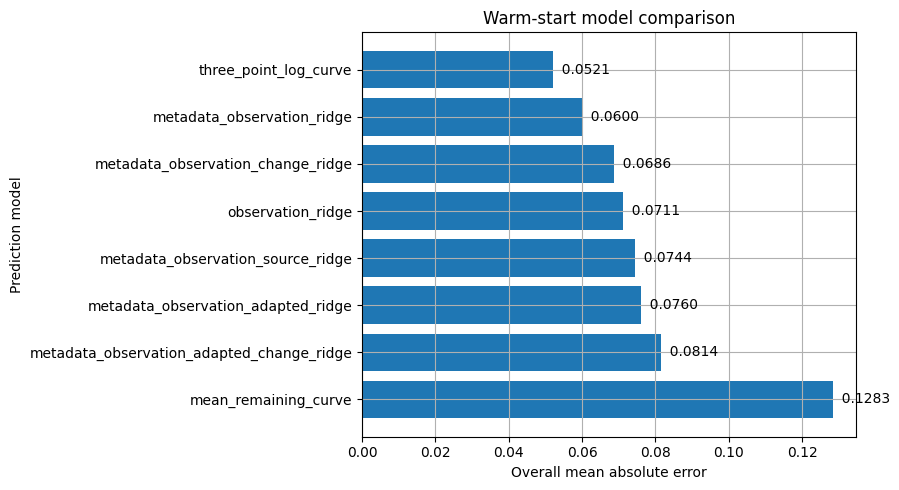

In [14]:
warm_ranking_df = (
    warm_summary_df
    .sort_values("overall_mae")
    .reset_index(drop=True)
)

plt.figure(figsize=(9, 5))
bars = plt.barh(
    warm_ranking_df["prediction_model"],
    warm_ranking_df["overall_mae"],
)

plt.xlabel("Overall mean absolute error")
plt.ylabel("Prediction model")
plt.title("Warm-start model comparison")
plt.gca().invert_yaxis()

for bar, mae in zip(
    bars,
    warm_ranking_df["overall_mae"],
):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"  {mae:.4f}",
        va="center",
    )

plt.tight_layout()
plt.show()


### Warm-start error by nominal predicted budget

Warm-start MAE is reported only at 25%, 50%, and 100%, because zero shot, 5%, and 10% are already observed when the warm-start forecast is made.


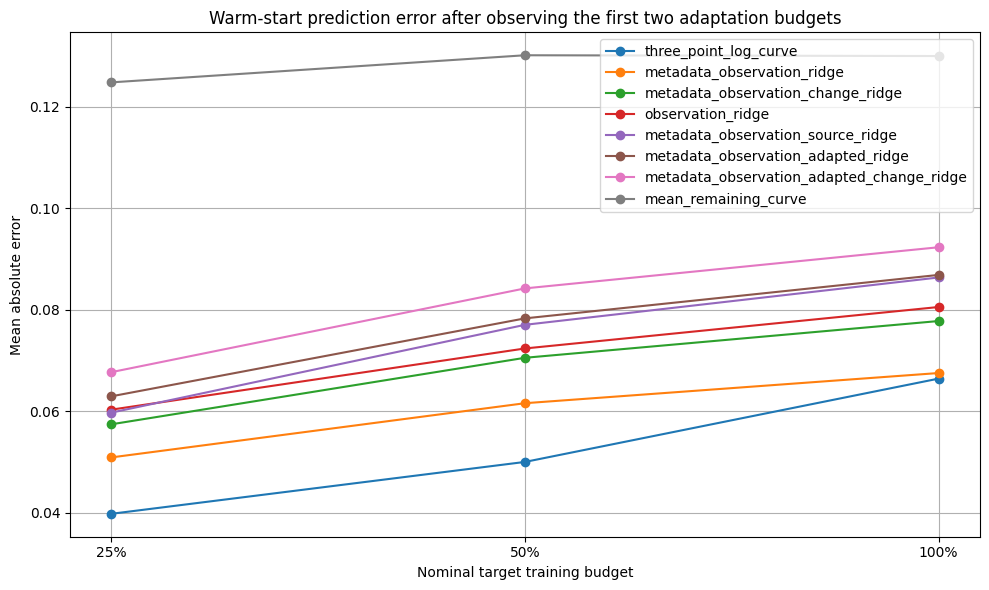

In [15]:
warm_points = [25, 50, 100]
warm_model_names = warm_summary_df["prediction_model"].tolist()
x_positions = np.arange(len(warm_points))

plt.figure(figsize=(10, 6))

for prediction_model in warm_model_names:
    row = warm_summary_df[
        warm_summary_df["prediction_model"] == prediction_model
    ].iloc[0]

    plt.plot(
        x_positions,
        [row[f"mae_{point}"] for point in warm_points],
        marker="o",
        label=prediction_model,
    )

plt.xticks(
    x_positions,
    [f"{point}%" for point in warm_points],
)
plt.xlabel("Nominal target training budget")
plt.ylabel("Mean absolute error")
plt.title(
    "Warm-start prediction error after observing "
    "the first two adaptation budgets"
)
plt.legend()
plt.tight_layout()
plt.show()


### Warm-start error by held-out target domain


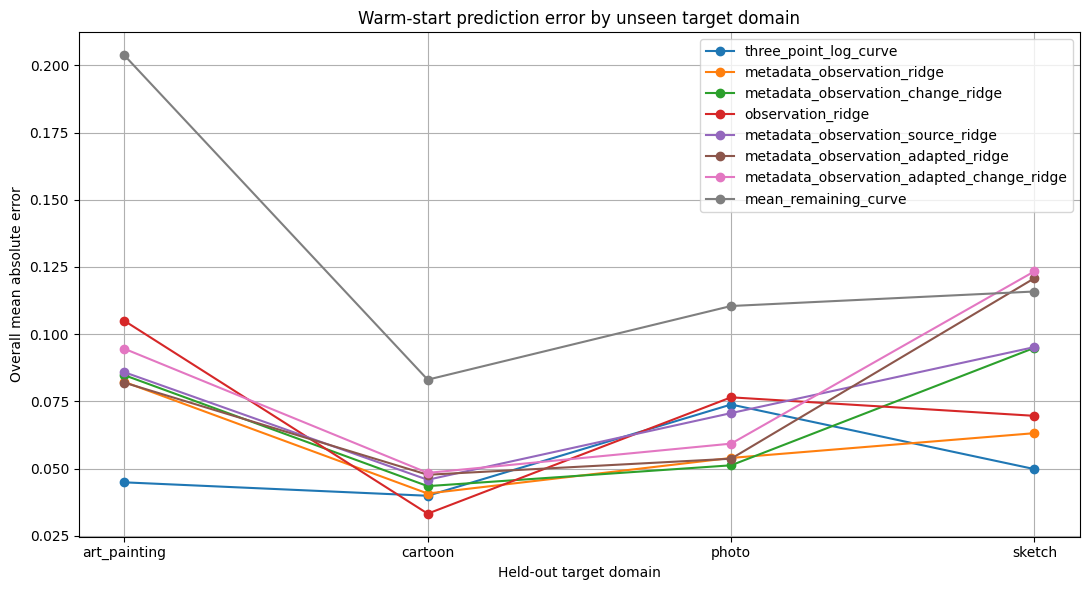

In [16]:
warm_targets = sorted(
    warm_fold_df["held_out_target"].unique()
)
x_positions = np.arange(len(warm_targets))

plt.figure(figsize=(11, 6))

for prediction_model in warm_model_names:
    target_maes = []

    for held_out_target in warm_targets:
        row = warm_fold_df[
            (warm_fold_df["prediction_model"] == prediction_model)
            & (warm_fold_df["held_out_target"] == held_out_target)
        ].iloc[0]

        target_maes.append(row["overall_mae"])

    plt.plot(
        x_positions,
        target_maes,
        marker="o",
        label=prediction_model,
    )

plt.xticks(x_positions, warm_targets)
plt.xlabel("Held-out target domain")
plt.ylabel("Overall mean absolute error")
plt.title("Warm-start prediction error by unseen target domain")
plt.legend()
plt.tight_layout()
plt.show()


### Example warm-start learning curve

Validation observations and test-set ground truth are shown as **different series** because they are not measurements from the same evaluation set.

The power-law predictors are continuous curves from predicted $[A_0,a,c]$. The three-point log baseline is reconstructed from the three observed validation accuracies and the exact sample counts. The example includes the strongest Ridge model and the strongest discrepancy-based Ridge variant from the current experiment.


In [17]:
def plot_warm_start_case(
    predictions_df,
    dataset_df,
    case_id,
    prediction_models=None,
):
    case_df = predictions_df[
        predictions_df["case_id"] == case_id
    ].copy()

    if case_df.empty:
        raise ValueError(f"Unknown case_id: {case_id}")

    if prediction_models is not None:
        case_df = case_df[
            case_df["prediction_model"].isin(prediction_models)
        ]

    if case_df.empty:
        raise ValueError(
            "No rows remain after applying prediction_models."
        )

    dataset_rows = dataset_df[
        dataset_df["case_id"] == case_id
    ]

    if len(dataset_rows) != 1:
        raise ValueError(
            "Warm-start dataset must contain one row for the case."
        )

    first_row = case_df.iloc[0]
    data_row = dataset_rows.iloc[0]

    all_points = [0, 5, 10, 25, 50, 100]
    n_values = np.array(
        [data_row[f"n_{point}"] for point in all_points],
        dtype=float,
    )
    test_values = np.array(
        [data_row[f"accuracy_{point}"] for point in all_points],
        dtype=float,
    )

    observed_n = np.array(
        [0, data_row["n_5"], data_row["n_10"]],
        dtype=float,
    )
    observed_validation = np.array(
        [
            data_row["zero_shot_val_accuracy"],
            data_row["best_val_accuracy_5"],
            data_row["best_val_accuracy_10"],
        ],
        dtype=float,
    )

    dense_n = np.linspace(0, n_values.max(), 400)

    actual_curve = power_law_curve(
        dense_n,
        data_row["curve_a0"],
        data_row["curve_a"],
        data_row["curve_c"],
    )

    plt.figure(figsize=(10, 6))

    plt.plot(
        dense_n,
        actual_curve,
        linewidth=3,
        label="fitted ground-truth test curve",
    )
    plt.scatter(
        n_values,
        test_values,
        s=70,
        label="measured test accuracy",
        zorder=5,
    )
    plt.scatter(
        observed_n,
        observed_validation,
        marker="x",
        s=90,
        label="observed validation accuracy",
        zorder=6,
    )

    for _, row in case_df.iterrows():
        model_name = row["prediction_model"]

        if model_name == "three_point_log_curve":
            design = np.column_stack([
                np.ones(3),
                np.log1p(observed_n),
            ])
            coefficients = np.linalg.lstsq(
                design,
                observed_validation,
                rcond=None,
            )[0]

            dense_predictions = (
                np.column_stack([
                    np.ones(len(dense_n)),
                    np.log1p(dense_n),
                ])
                @ coefficients
            )

            dense_predictions = np.clip(
                dense_predictions,
                0.0,
                1.0,
            )

        else:
            predicted_parameters = [
                row["predicted_curve_a0"],
                row["predicted_curve_a"],
                row["predicted_curve_c"],
            ]

            dense_predictions = power_law_curve(
                dense_n,
                *predicted_parameters,
            )

        plt.plot(
            dense_n,
            dense_predictions,
            linestyle="--",
            label=model_name,
        )

    plt.xlabel("Number of target training examples (n)")
    plt.ylabel("Accuracy")
    plt.title(
        "Warm-start learning-curve prediction\n"
        f"{first_row['sources']} → {first_row['target']} | "
        f"{first_row['model']} | seed {int(first_row['seed'])}"
    )
    plt.ylim(0.0, 1.0)
    plt.legend()
    plt.tight_layout()
    plt.show()


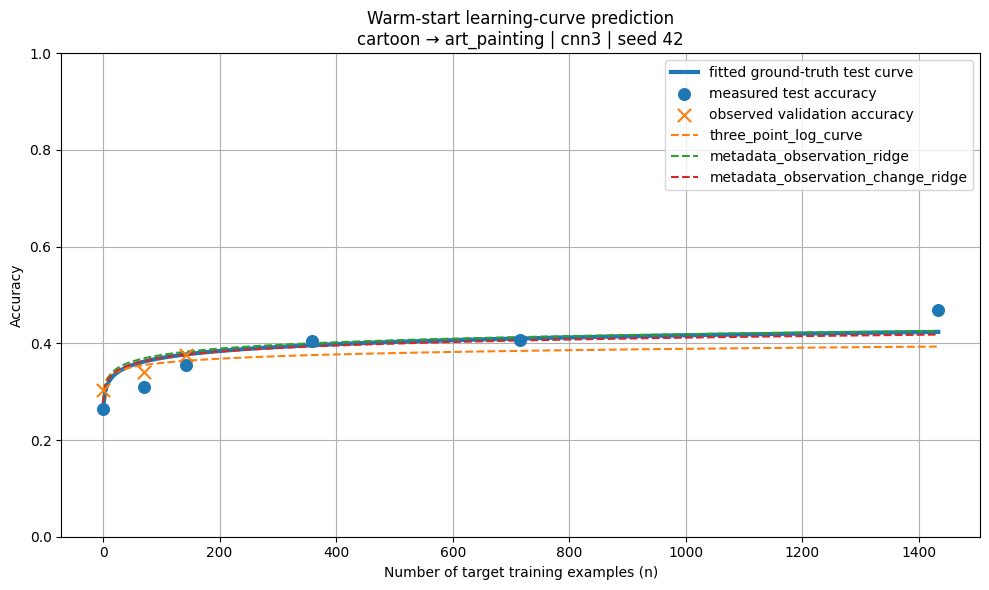

In [18]:
example_warm_case_id = warm_predictions_df["case_id"].iloc[0]

plot_warm_start_case(
    warm_predictions_df,
    warm_dataset_df,
    case_id=example_warm_case_id,
    prediction_models=[
        "three_point_log_curve",
        "metadata_observation_ridge",
        "metadata_observation_change_ridge",
    ],
)


## Ridge interpretation and feature ablation

Stage 8 computes the interpretability diagnostics used below, while this notebook only loads and visualizes those outputs. The cold-start analysis uses standardized Ridge coefficients and leave-one-feature-out (LOFO) ablation. The warm-start analysis keeps the coefficient view but uses the correlation structure to motivate **grouped** rather than single-feature ablation.

Coefficient magnitude and ablation effects are properties of these fitted predictors, not causal importance.


### Cold-start standardized Ridge coefficients

Numeric inputs are standardized inside the Ridge pipeline. Stage 8 additionally divides each fitted coefficient by the corresponding curve parameter's standard deviation in that outer training fold. The summary therefore gives an approximate change in target-standard-deviation units for a one-standard-deviation change in an input, conditional on the other predictors.

`sign_consistency` ranges from 0 to 1. Because a feature can legitimately relate differently to $A_0$, $a$, and $c$, the parameter-level table should be used when interpreting signs.


In [19]:
cold_coefficient_summary_df


,feature,mean_abs_standardized_coefficient,mean_standardized_coefficient,sign_consistency
0,zero_shot_val_accuracy,0.417687,0.263311,0.000000
1,n_5,0.219818,0.107572,0.166667
2,source_accuracy,0.154262,-0.147117,0.833333
3,zero_shot_val_loss,0.121702,0.030626,0.500000
4,source_size,0.062456,0.058511,0.666667


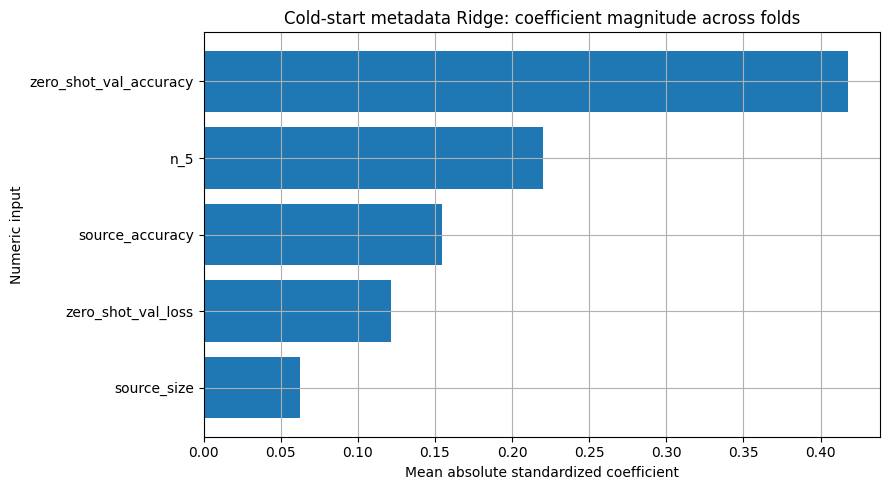

,parameter,feature,mean_coefficient,mean_abs_coefficient,sign_consistency
0,curve_a,source_accuracy,-0.213806,0.213806,1.0
1,curve_a,zero_shot_val_loss,-0.064490,0.176860,0.5
2,curve_a,n_5,-0.152240,0.152240,1.0
3,curve_a,source_size,0.099987,0.099987,1.0
4,curve_a,zero_shot_val_accuracy,-0.065049,0.082103,0.5
5,curve_a0,zero_shot_val_accuracy,0.944241,0.944241,1.0
6,curve_a0,source_size,0.076665,0.076665,1.0
7,curve_a0,source_accuracy,-0.062098,0.062098,1.0
8,curve_a0,zero_shot_val_loss,0.028522,0.047454,0.5
9,curve_a0,n_5,0.008140,0.040400,0.5


In [20]:
plt.figure(figsize=(9, 5))
plot_df = cold_coefficient_summary_df.iloc[::-1]
plt.barh(plot_df["feature"], plot_df["mean_abs_standardized_coefficient"])
plt.xlabel("Mean absolute standardized coefficient")
plt.ylabel("Numeric input")
plt.title("Cold-start metadata Ridge: coefficient magnitude across folds")
plt.tight_layout()
plt.show()

cold_parameter_coefficients_df


### Cold-start leave-one-feature-out ablation

Cold start has a small metadata feature set, so individual ablation remains reasonably interpretable. Stage 8 removes one input at a time and reruns the complete nested leave-one-target-domain-out evaluation, including inner Ridge-alpha selection.

$$
\Delta\mathrm{MAE}=\mathrm{MAE}_{\mathrm{without\ feature}}-\mathrm{MAE}_{\mathrm{full}}.
$$

A positive value means held-out prediction becomes worse without that input; a negative value means the reduced model performs better. This measures incremental predictive dependence, not causal importance.


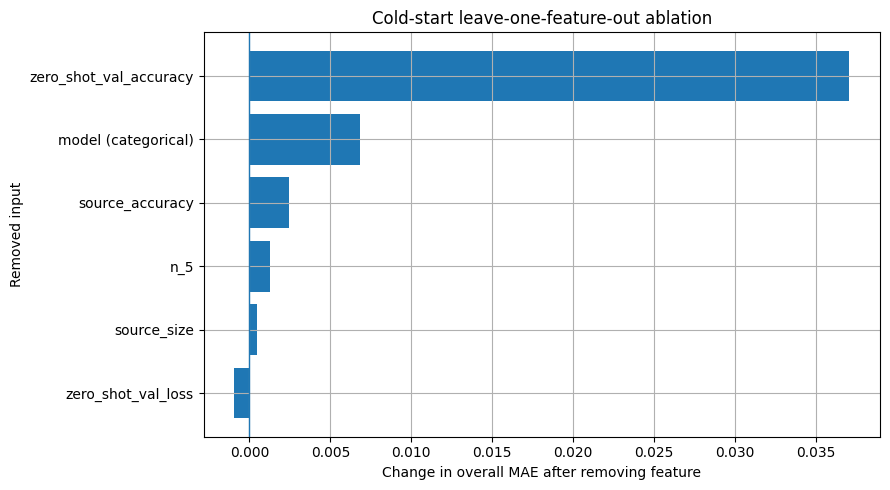

In [21]:
cold_ablation_df

cold_ablation_plot_df = cold_ablation_df[
    cold_ablation_df["removed_feature"] != "(none: full model)"
].sort_values("delta_mae_vs_full")

plt.figure(figsize=(9, 5))
plt.barh(cold_ablation_plot_df["removed_feature"], cold_ablation_plot_df["delta_mae_vs_full"])
plt.axvline(0.0, linewidth=1)
plt.xlabel("Change in overall MAE after removing feature")
plt.ylabel("Removed input")
plt.title("Cold-start leave-one-feature-out ablation")
plt.tight_layout()
plt.show()


### Warm-start standardized Ridge coefficients

The same standardized-coefficient analysis is applied to the main warm-start metadata + observation Ridge. These coefficients should be interpreted together with the correlation analysis below, because several warm-start inputs encode nearly the same information.


In [22]:
warm_coefficient_summary_df


,feature,mean_abs_standardized_coefficient,mean_standardized_coefficient,sign_consistency
0,zero_shot_val_accuracy,0.510374,0.090047,0.166667
1,best_val_accuracy_5,0.324993,0.056437,0.333333
2,best_val_accuracy_10,0.305842,0.062593,0.833333
3,optimization_steps_5,0.299376,-0.279788,0.500000
4,optimization_steps_10,0.182726,0.131089,0.500000
5,best_train_accuracy_10,0.155700,0.053397,0.000000
6,best_train_accuracy_5,0.152457,0.095788,0.333333
7,zero_shot_val_loss,0.132895,0.003736,0.166667
8,n_5,0.107481,0.073727,0.333333
9,source_accuracy,0.102940,-0.082862,0.333333


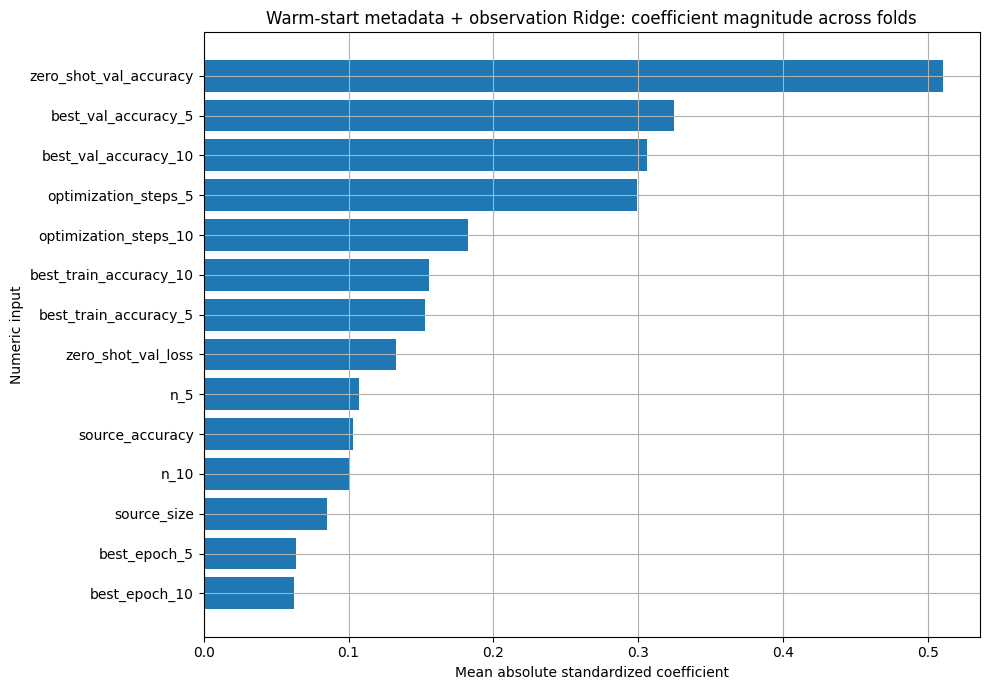

,parameter,feature,mean_coefficient,mean_abs_coefficient,sign_consistency
0,curve_a,best_val_accuracy_5,-0.201788,0.570330,0.5
1,curve_a,best_val_accuracy_10,-0.269093,0.460655,0.5
2,curve_a,optimization_steps_5,-0.399414,0.427591,0.0
3,curve_a,best_train_accuracy_5,0.256903,0.256903,1.0
4,curve_a,source_accuracy,-0.228399,0.228399,1.0
5,curve_a,optimization_steps_10,0.225579,0.227175,0.5
6,curve_a,best_train_accuracy_10,0.053853,0.219759,0.5
7,curve_a,zero_shot_val_loss,-0.058239,0.197114,0.5
8,curve_a,zero_shot_val_accuracy,0.047075,0.187013,0.5
9,curve_a,source_size,0.132809,0.132809,1.0


In [23]:
plt.figure(figsize=(10, 7))
plot_df = warm_coefficient_summary_df.iloc[::-1]
plt.barh(plot_df["feature"], plot_df["mean_abs_standardized_coefficient"])
plt.xlabel("Mean absolute standardized coefficient")
plt.ylabel("Numeric input")
plt.title("Warm-start metadata + observation Ridge: coefficient magnitude across folds")
plt.tight_layout()
plt.show()

warm_parameter_coefficients_df


### Warm-start feature correlations

Several warm-start predictors are strongly correlated, so individual coefficients can divide or suppress shared signal and single-feature ablations can be unstable or misleading. The correlation matrix is therefore used to identify redundant information before ablation.


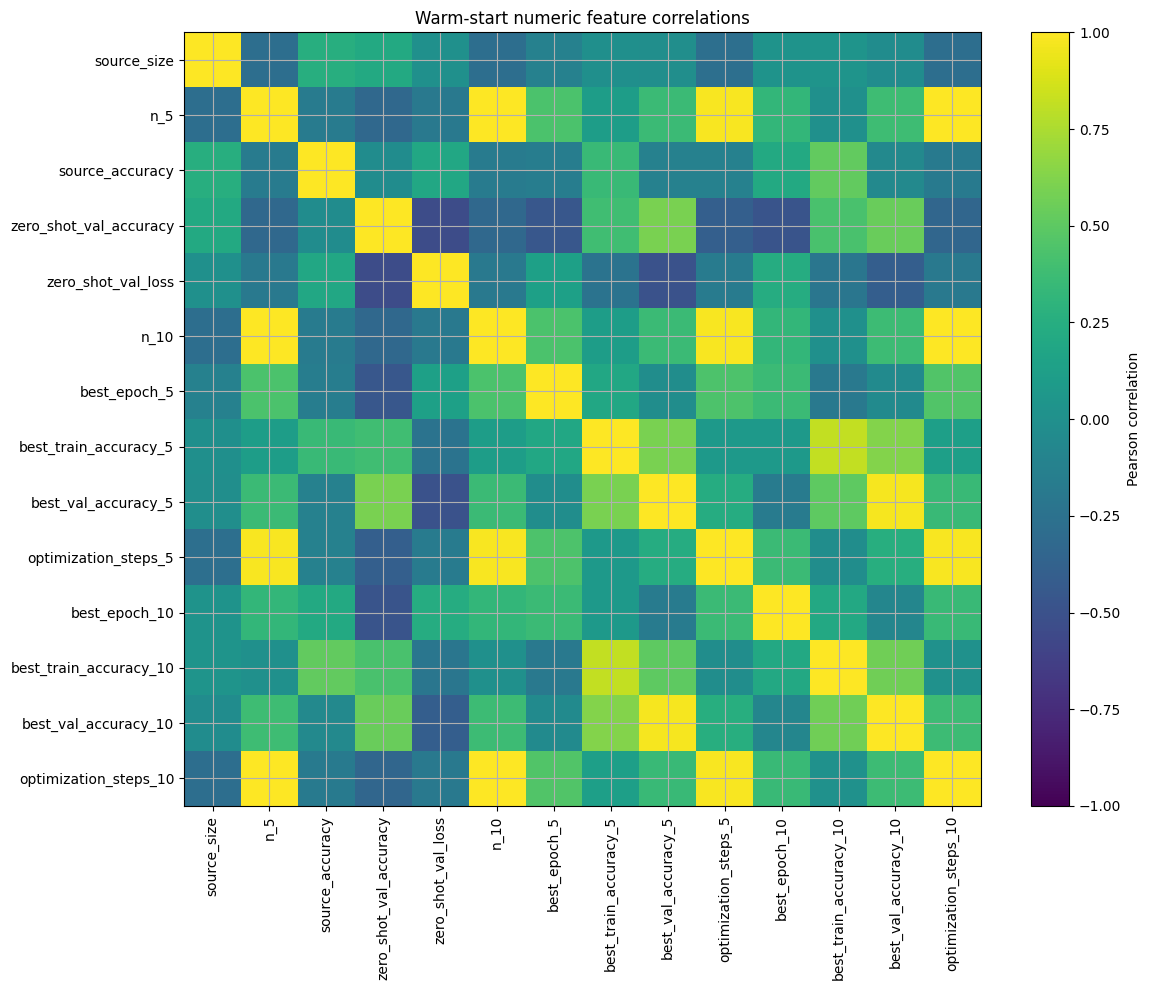

,feature_1,feature_2,correlation,absolute_correlation
0,n_5,n_10,0.999991,0.999991
1,n_5,optimization_steps_10,0.994329,0.994329
2,n_10,optimization_steps_10,0.994029,0.994029
3,n_10,optimization_steps_5,0.983736,0.983736
4,n_5,optimization_steps_5,0.983248,0.983248
5,optimization_steps_5,optimization_steps_10,0.981023,0.981023
6,best_val_accuracy_5,best_val_accuracy_10,0.970736,0.970736
7,best_train_accuracy_5,best_train_accuracy_10,0.819589,0.819589
8,best_train_accuracy_5,best_val_accuracy_10,0.632002,0.632002
9,best_train_accuracy_5,best_val_accuracy_5,0.601053,0.601053


In [24]:
plt.figure(figsize=(12, 10))
image = plt.imshow(warm_correlation_df.to_numpy(), vmin=-1, vmax=1, aspect="auto")
plt.colorbar(image, label="Pearson correlation")
plt.xticks(np.arange(len(warm_correlation_df.columns)), warm_correlation_df.columns, rotation=90)
plt.yticks(np.arange(len(warm_correlation_df.index)), warm_correlation_df.index)
plt.title("Warm-start numeric feature correlations")
plt.tight_layout()
plt.show()

warm_strongest_correlations_df.head(15)


### Warm-start grouped feature ablation

Because the warm-start predictors contain strongly correlated families, Stage 8 skips single-feature LOFO and removes coherent **information groups** instead. Each reduced feature set reruns the complete nested leave-one-target-domain-out Ridge evaluation, including inner alpha selection.

The groups are:

- **Source / zero-shot context:** source dataset/model context and zero-shot validation signals.
- **Budget / training amount:** 5%/10% sample counts and optimization-step counts.
- **Training dynamics:** best epochs and training accuracies from the 5% and 10% runs.
- **Early validation performance:** validation accuracies after the 5% and 10% runs.

A positive `delta_mae_vs_full` means removing the whole information family worsens prediction; a negative value means the reduced model performs better.


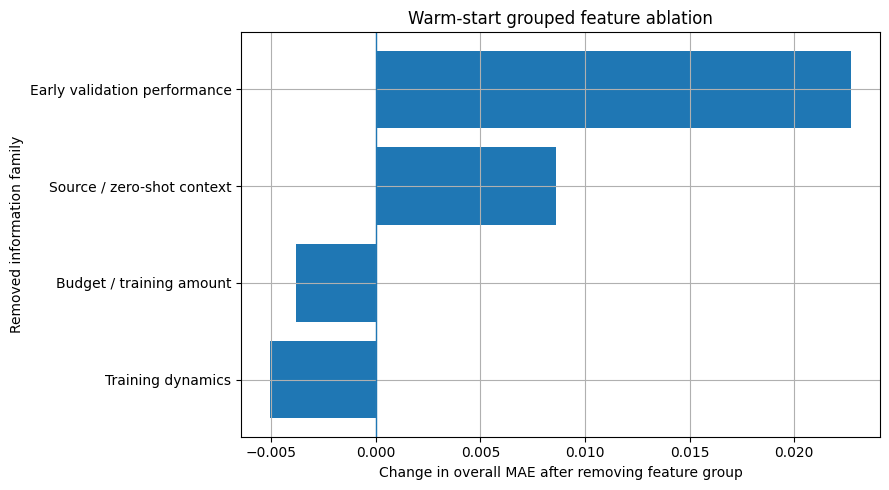

In [25]:
warm_grouped_ablation_df

warm_grouped_ablation_plot_df = warm_grouped_ablation_df[
    warm_grouped_ablation_df["removed_group"] != "(none: full model)"
].sort_values("delta_mae_vs_full")

plt.figure(figsize=(9, 5))
plt.barh(warm_grouped_ablation_plot_df["removed_group"], warm_grouped_ablation_plot_df["delta_mae_vs_full"])
plt.axvline(0.0, linewidth=1)
plt.xlabel("Change in overall MAE after removing feature group")
plt.ylabel("Removed information family")
plt.title("Warm-start grouped feature ablation")
plt.tight_layout()
plt.show()


### How to read these analyses

For cold start, the small feature set makes the coefficient and LOFO views useful together. For warm start, the correlation matrix shows that several predictors are highly redundant, so the grouped ablation is the primary incremental-information diagnostic rather than single-feature LOFO.

A positive grouped-ablation effect means that an information family helps prediction conditional on the remaining families. A negative effect can indicate redundancy or noise. These are descriptive diagnostics for the PACS pilot, not evidence of causal mechanisms or universal generalization; broader validation across datasets, model families, and adaptation procedures belongs to the proposed PhD research.
